# PE7023 - Project
## Part1.2


Diego de Miranda Gomes

Emuobosa Patience Ojoboh

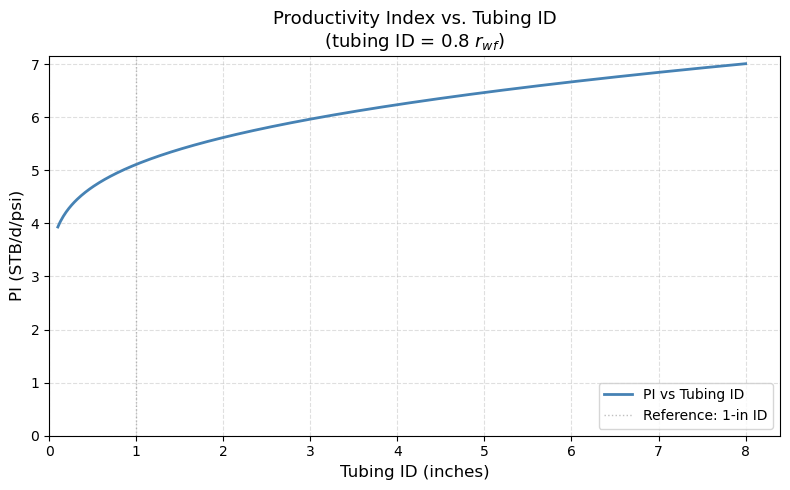


 Tubing ID (in)   rwf (in)   PI (STB/d/psi)
--------------------------------------------
            1.0       1.25           5.1113
            2.0       2.50           5.6183
            3.0       3.75           5.9644
            4.0       5.00           6.2370
            5.0       6.25           6.4663
            6.0       7.50           6.6665
            7.0       8.75           6.8456
            8.0      10.00           7.0088


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ── Reservoir data ────────────────────────────────────────────────────────────
k   = 40       # permeability, mDarcy
h   = 150      # pay thickness, ft
re  = 372      # drainage radius, ft
S   = 0        # skin factor
Bo  = 1.2      # oil formation volume factor, RB/STB
mu  = 0.902    # oil viscosity in reservoir, cp

# ── Part 2 setup ──────────────────────────────────────────────────────────────
# Given: tubing ID = 0.8 * rwf  →  rwf = ID / 0.8
# Sweep tubing ID from 0.1 to 8 inches, convert to feet for the PI equation

ID_in  = np.linspace(0.1, 8.0, 500)          # tubing ID in inches
ID_ft  = ID_in / 12                            # convert to feet
rwf_ft = ID_ft / 0.8                           # wellbore radius in feet

# ── PI calculation (Darcy steady-state, corrected with mu_o) ─────────────────
# PI = kh / [ 141.2 * Bo * mu * ( ln(re/rwf) - 0.5 + S ) ]   [STB/d/psi]
PI = (k * h) / (141.2 * Bo * mu * (np.log(re / rwf_ft) - 0.5 + S))

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(ID_in, PI, color='steelblue', linewidth=2, label='PI vs Tubing ID')

# Asphaltene constraint reference line (noted here for context — used in Part 3)
ax.axvline(x=1.0, color='gray', linestyle=':', linewidth=1, alpha=0.5,
           label='Reference: 1-in ID')

ax.set_xlabel('Tubing ID (inches)', fontsize=12)
ax.set_ylabel('PI (STB/d/psi)', fontsize=12)
ax.set_title('Productivity Index vs. Tubing ID\n'
             r'(tubing ID = 0.8 $r_{wf}$)', fontsize=13)
ax.legend()
ax.grid(True, linestyle='--', alpha=0.4)
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)

plt.tight_layout()
plt.savefig('PI_vs_TubingID.png', dpi=150)
plt.show()

# ── Print a summary table for a few key IDs ───────────────────────────────────
print(f"\n{'Tubing ID (in)':>15} {'rwf (in)':>10} {'PI (STB/d/psi)':>16}")
print("-" * 44)
spot_IDs = [1, 2, 3, 4, 5, 6, 7, 8]
for d in spot_IDs:
    r = d / 0.8
    p = (k * h) / (141.2 * Bo * mu * (np.log(re / (r/12)) - 0.5 + S))
    print(f"{d:>15.1f} {r:>10.2f} {p:>16.4f}")